In [1]:
import torch
import gpytorch
import matplotlib.pyplot as plt

from sample import PosteriorSample
from gp import SVGP, train_svgp

In [5]:
n = 20
x = torch.rand((n, 1)) * 6 - 3.0
K = 2 * torch.exp( - torch.cdist(x, x).square() / 2)
L = torch.linalg.cholesky(K + torch.eye(n) * 0.0001)
y = torch.randn((n,)) @ L.T

100%|██████████| 500/500 [00:00<00:00, 570.11it/s]


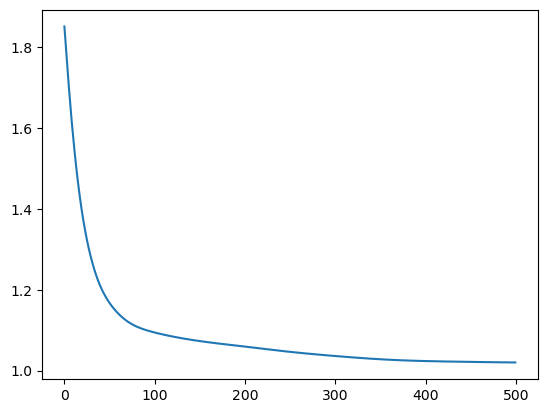

In [6]:
svgp = SVGP(torch.rand((8, 1)))
lik = gpytorch.likelihoods.GaussianLikelihood()

loss_evo = train_svgp(svgp, lik, x, y, steps=500, lr=1e-2)
plt.plot(loss_evo)
plt.show()

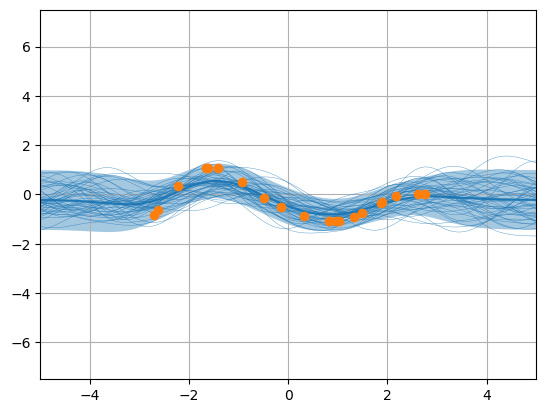

In [7]:
xs = torch.linspace(-5.0, 5.0, 200).unsqueeze(1)
for _ in range(50):
    f_i = PosteriorSample(svgp)
    f_i_x = f_i(xs)
    plt.plot(xs, f_i_x.detach(), color='C0', alpha=0.8, linewidth=0.3)
with torch.no_grad():
    f_post = svgp(xs)
plt.plot(xs, f_post.mean, color='C0')
plt.scatter(x.squeeze(), y, color='C1', zorder=10000)
plt.grid()
plt.ylim([-7.5, 7.5])
plt.xlim([xs.min(), xs.max()])
plt.fill_between(xs.squeeze(), f_post.mean+2*f_post.variance.sqrt(), f_post.mean-2*f_post.variance.sqrt(), alpha=0.4)
plt.show()